<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machina_learning/lab%20-%20Ordinary%20Least%20Squares%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ordinary Least Squares (OLS) Linear Regression from Scratch

## Introduction

**Linear regression** is the foundational supervised learning algorithm for predicting a continuous target variable $y$ from input features $\mathbf{x}$.

### Statistical Model

We assume:
$$y^{(i)} = \boldsymbol{\theta}^\top \mathbf{x}^{(i)} + \varepsilon^{(i)}, \quad \varepsilon^{(i)} \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0, \sigma^2)$$

where $\boldsymbol{\theta}$ is the parameter vector we wish to learn, and $\varepsilon^{(i)}$ is Gaussian noise.

### MLE Connection to Least Squares

Under this model, the likelihood of the data is:
$$\mathcal{L}(\boldsymbol{\theta}) = \prod_{i=1}^m P(y^{(i)} \mid \mathbf{x}^{(i)}; \boldsymbol{\theta}) = \prod_{i=1}^m \frac{1}{\sqrt{2\pi}\sigma} \exp\!\left(-\frac{(y^{(i)} - \boldsymbol{\theta}^\top\mathbf{x}^{(i)})^2}{2\sigma^2}\right)$$

Maximizing $\mathcal{L}$ (equivalently, minimizing the negative log-likelihood) gives:
$$\arg\max_{\boldsymbol{\theta}} \mathcal{L}(\boldsymbol{\theta}) = \arg\min_{\boldsymbol{\theta}} \sum_{i=1}^m (y^{(i)} - \boldsymbol{\theta}^\top\mathbf{x}^{(i)})^2$$

**Conclusion:** minimizing mean squared error is equivalent to maximum likelihood estimation under Gaussian noise.

### Learning Objectives
- Implement the MSE cost function from scratch
- Derive and implement batch gradient descent
- Implement the closed-form Normal Equation and compare
- Vectorize the implementation for efficiency
- Compute $R^2$ to assess model fit

<div align='center'>

![Linear Regression](https://upload.wikimedia.org/wikipedia/commons/3/3a/Linear_regression.svg)

*Linear regression finds the line (or hyperplane) that best fits the data by minimizing the sum of squared residuals.*

</div>

In [1]:
%matplotlib inline
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
import time

plt.style.use('seaborn-v0_8-whitegrid')

## Notation

Throughout this notebook we use the following unified notation:

| Symbol | Meaning |
|--------|---------|
| $m$ | Number of training samples |
| $n$ | Number of features (before bias augmentation) |
| $\mathbf{X} \in \mathbb{R}^{m \times (n+1)}$ | Design matrix (augmented with a column of ones) |
| $\mathbf{x}^{(i)} \in \mathbb{R}^{n+1}$ | $i$-th training example (augmented) |
| $y^{(i)} \in \mathbb{R}$ | $i$-th target value |
| $\boldsymbol{\theta} \in \mathbb{R}^{n+1}$ | Parameter vector (includes bias $\theta_0$) |
| $\hat{y}^{(i)} = h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) = \boldsymbol{\theta}^\top\mathbf{x}^{(i)}$ | Predicted output |
| $\mathcal{J}(\boldsymbol{\theta})$ | MSE cost function |
| $\alpha$ | Learning rate |

The augmented design matrix is:
$$\mathbf{X} = \begin{bmatrix} 1 & x_1^{(1)} & \cdots & x_n^{(1)} \\ 1 & x_1^{(2)} & \cdots & x_n^{(2)} \\ \vdots & & \ddots & \vdots \\ 1 & x_1^{(m)} & \cdots & x_n^{(m)} \end{bmatrix} \in \mathbb{R}^{m \times (n+1)}$$

#### Import the data
Here, we're using a dataset with two columns containing the amount of hours studied and the test scores students achieved, respectively.

In [2]:
# Generate random data
np.random.seed(0)
m = 1000
X = np.random.rand(m, 1) * 10  # Generate 100 data points between 0 and 10
y = 2 * X + 1 + np.random.randn(m, 1) * 2  # Create target values with some noise

m, n = X.shape

print(f"Num features : {n}")
print(f"Num samples  : {m}")

Num features : 1
Num samples  : 1000


In [3]:
print(f"y shape before squeeze: {y.shape}")

y shape before squeeze: (1000, 1)


In [4]:
y = y.squeeze()

In [5]:
print(f"y shape after squeeze : {y.shape}")

y shape after squeeze : (1000,)


Let's plot the data.

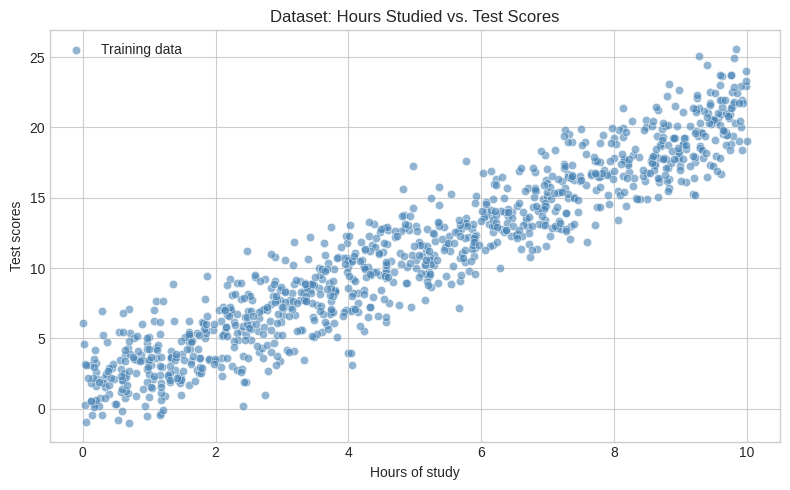

In [6]:
# Plot the dataset
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, edgecolors='white', linewidths=0.5,
            color='steelblue', label='Training data')
plt.xlabel('Hours of study')
plt.ylabel('Test scores')
plt.title('Dataset: Hours Studied vs. Test Scores')
plt.legend()
plt.tight_layout()
plt.show()

Before continuing, we will add the first column of all 1's ($x_0$ for the intercept term).

In [7]:
print(f"X shape before augmentation : {X.shape}")
X = np.concatenate([np.ones((m, 1)), X], axis=1)
print(f"X shape after augmentation  : {X.shape}")
print("First 5 rows of X:")
print(X[:5, :])

X shape before augmentation : (1000, 1)
X shape after augmentation  : (1000, 2)
First 5 rows of X:
[[1.         5.48813504]
 [1.         7.15189366]
 [1.         6.02763376]
 [1.         5.44883183]
 [1.         4.23654799]]


#### Defining the hyperparamters

In [8]:
# Hyperparameters
learning_rate = 0.01
initial_theta_vector = np.zeros(X.shape[1])
num_iterations = 100

print("-" * 40)
print("Hyperparameter Configuration")
print("-" * 40)
print(f"  Learning rate    : {learning_rate}")
print(f"  Num iterations   : {num_iterations}")
print(f"  Initial theta    : {initial_theta_vector}")
print("-" * 40)

----------------------------------------
Hyperparameter Configuration
----------------------------------------
  Learning rate    : 0.01
  Num iterations   : 100
  Initial theta    : [0. 0.]
----------------------------------------


Could you have used a different initial_theta_vector?


#### Define the Cost Function

We use the **Mean Squared Error (MSE)** cost function:

$$\mathcal{J}(\boldsymbol{\theta}) = \frac{1}{2m}\sum_{i=1}^m\bigl(h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) - y^{(i)}\bigr)^2 = \frac{1}{2m}\|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|^2$$

**Why the $\frac{1}{2m}$ factor?**  
- $\frac{1}{m}$ normalizes by the number of samples so the cost does not grow with $m$  
- $\frac{1}{2}$ cancels the factor of 2 from differentiation: $\frac{d}{d\theta}(\theta - y)^2 = 2(\theta-y)$, making the gradient formula cleaner

The hypothesis is the linear model: $h_{\boldsymbol{\theta}}(\mathbf{x}) = \boldsymbol{\theta}^\top\mathbf{x} = \theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n$

In [9]:
def compute_cost(theta_vector, X, y):
    """Compute MSE cost (loop-based) for parameter vector theta_vector."""
    total_cost = 0

    # number of datapoints in training data
    m = len(y)

    # Compute sum of squared errors (without the 1/2m term)
    """
    Enter your solution here.
    """
    for i in range(m):
        total_cost += (np.dot(theta_vector, X[i, :]) - y[i]) ** 2

    # Return average of squared error
    return total_cost / (2 * m)

Check your compute_cost implementetation.

In [10]:
initial_cost = compute_cost(initial_theta_vector, X, y)
print(f"Initial cost (should be ~78.6) : {initial_cost:.4f}")


Initial cost (should be ~78.6) : 78.6707


should be 78.6


#### Gradient Descent

To minimize $\mathcal{J}(\boldsymbol{\theta})$, we repeatedly update $\boldsymbol{\theta}$ in the direction of the negative gradient.

**Gradient derivation (component form):**

$$\frac{\partial \mathcal{J}}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^m \bigl(h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) - y^{(i)}\bigr) x_j^{(i)}$$

**Vectorized form** (all $j$ simultaneously):

$$\nabla_{\boldsymbol{\theta}}\mathcal{J}(\boldsymbol{\theta}) = \frac{1}{m}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$$

**Update rule** (batch gradient descent):

$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha \nabla_{\boldsymbol{\theta}}\mathcal{J}(\boldsymbol{\theta})$$

Since the MSE cost is **strictly convex** in $\boldsymbol{\theta}$ (the Hessian $\mathbf{H} = \frac{1}{m}\mathbf{X}^\top\mathbf{X}$ is positive semi-definite), gradient descent converges to the **global minimum** for a sufficiently small learning rate $\alpha < \frac{2}{\lambda_{\max}(\mathbf{H})}$, where $\lambda_{\max}$ is the largest eigenvalue of $\mathbf{H}$.

<div align='center'>

![Gradient Descent](https://upload.wikimedia.org/wikipedia/commons/f/ff/Gradient_descent.svg)

*Gradient descent iteratively moves the parameters in the direction of steepest descent of the cost surface until convergence.*

</div>

In [11]:
def step_gradient(theta_current, X, y, alpha):
    """takes one step down towards the minima

    Args:
        theta_current (float vector): current values of theta
        data (np.array): array containing the training data (x,y)
        alpha (float): learning rate / step size

    Returns:
        theta_updated (float vector): new values of theta
    """

    theta_gradient = np.zeros(X.shape[1])
    m = len(y)

    # Calculate Gradient
    for i in range(m):
        error_term = np.dot(X[i,:], theta_current) - y[i]
        theta_gradient += error_term * X[i,:] # Vectorized - all j's at once

    theta_gradient /= m

    # Update current theta vector
    theta_updated = theta_current - alpha * theta_gradient

    #Return updated parameters
    return theta_updated

In [12]:
theta_updated = step_gradient(initial_theta_vector, X, y, learning_rate)
print(f"Theta after one step (should be [0.5488, 3.5580]) : {theta_updated}")

Theta after one step (should be [0.5488, 3.5580]) : [0.10976519 0.71160567]


Should be [0.54882595 3.55802835]

And run steps of the gradient descent for as many iterations as wanted.

In [13]:
def gradient_descent(X, y, initial_theta_vector, learning_rate, num_iterations):
    """runs gradient descent

    Args:
        X (np.array): training data (features)
        y (np.array): training data pairs (outputs)
        initial_theta_vector (np.array): initial values of theta (random)
        learning_rate (float): hyperparameter to adjust the step size during descent
        num_iterations (int): hyperparameter, decides the number of iterations for which gradient descent would run

    Returns:
        tuple : (optimized_theta, cost_graph, theta_history)
            - optimized_theta : parameter vector at convergence
            - cost_graph      : list of MSE cost at each iteration
            - theta_history   : (num_iterations+1, 2) array of theta values,
                                starting from initial_theta_vector
    """

    # initial values
    theta_vector = initial_theta_vector.copy()

    # to store the cost and theta after each iteration
    cost_graph    = []
    theta_history = [theta_vector.copy()]

    # For every iteration, optimize the theta vector and compute its cost
    for i in range(num_iterations):
        cost_graph.append(compute_cost(theta_vector, X, y))
        theta_vector = step_gradient(theta_vector, X, y, learning_rate)
        theta_history.append(theta_vector.copy())

    return (theta_vector, cost_graph, np.array(theta_history))

#### Run gradient_descent() to get optimized parameters of theta

In [14]:
optimized_theta_vector, cost_graph, theta_history = gradient_descent(
    X, y, initial_theta_vector, learning_rate, num_iterations
)

final_cost = compute_cost(optimized_theta_vector, X, y)

print("-" * 45)
print("Gradient Descent Results")
print("-" * 45)
print(f"  theta_0 (intercept) : {optimized_theta_vector[0]:.6f}")
print(f"  theta_1 (slope)     : {optimized_theta_vector[1]:.6f}")
print(f"  Minimised cost (MSE): {final_cost:.6f}")
print("-" * 45)

---------------------------------------------
Gradient Descent Results
---------------------------------------------
  theta_0 (intercept) : 0.503681
  theta_1 (slope)     : 2.079002
  Minimised cost (MSE): 1.919488
---------------------------------------------


#### Plotting the cost per iterations

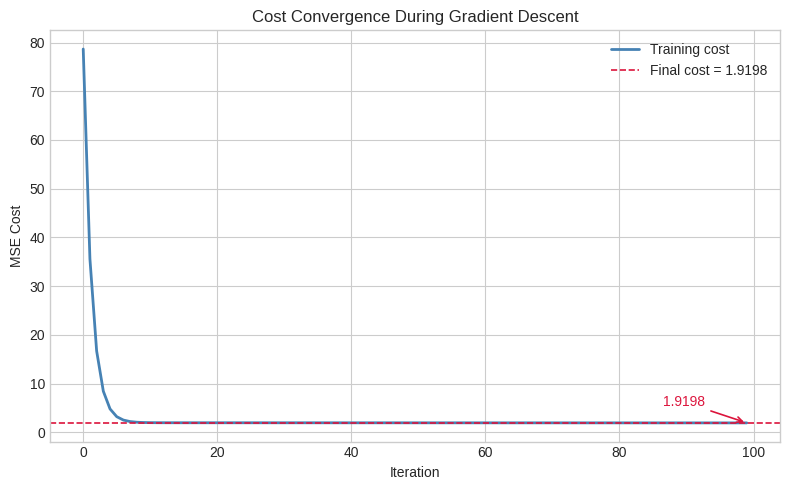

In [15]:
final_cost_val = cost_graph[-1]

plt.figure(figsize=(8, 5))
plt.plot(cost_graph, color='steelblue', linewidth=2, label='Training cost')
plt.axhline(y=final_cost_val, color='crimson', linestyle='--', linewidth=1.2,
            label=f'Final cost = {final_cost_val:.4f}')
plt.annotate(
    f'{final_cost_val:.4f}',
    xy=(len(cost_graph) - 1, final_cost_val),
    xytext=(-60, 12),
    textcoords='offset points',
    color='crimson',
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2)
)
plt.xlabel('Iteration')
plt.ylabel('MSE Cost')
plt.title('Cost Convergence During Gradient Descent')
plt.legend()
plt.tight_layout()
plt.show()


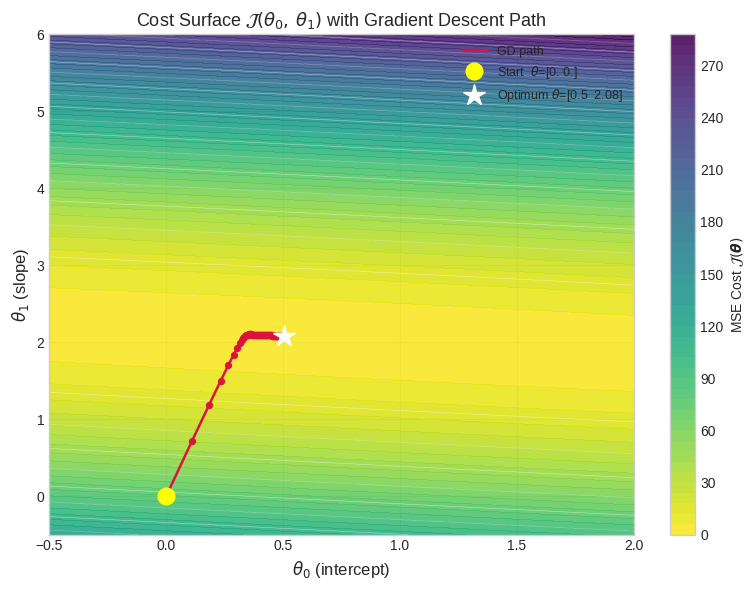

In [16]:
# ── Cost-surface contour + Gradient Descent path ──────────────────────────
# Build a (theta_0, theta_1) grid and evaluate J on it
t0_range = np.linspace(-0.5, 2.0, 300)
t1_range = np.linspace(-0.5, 6.0, 300)
T0, T1 = np.meshgrid(t0_range, t1_range)
J_grid = np.array([
    compute_cost(np.array([t0, t1]), X, y)
    for t0, t1 in zip(T0.ravel(), T1.ravel())
]).reshape(T0.shape)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(T0, T1, J_grid, levels=50, cmap='viridis_r', alpha=0.88)
ax.contour(T0, T1, J_grid, levels=20, colors='white', linewidths=0.4, alpha=0.5)
plt.colorbar(cp, ax=ax, label=r'MSE Cost $\mathcal{J}(\boldsymbol{\theta})$')

# Gradient descent trajectory
ax.plot(theta_history[:, 0], theta_history[:, 1],
        color='crimson', linewidth=1.8, zorder=3, label='GD path')
ax.scatter(theta_history[:, 0], theta_history[:, 1],
           c='crimson', s=18, zorder=4)

# Mark start and end
ax.plot(*theta_history[0],  'o', color='yellow', markersize=12,
        zorder=5, label=f'Start  $\\theta$={theta_history[0].round(2)}')
ax.plot(*theta_history[-1], '*', color='white',  markersize=16,
        zorder=5, label=f'Optimum $\\theta$={theta_history[-1].round(2)}')

ax.set_xlabel(r'$\theta_0$ (intercept)', fontsize=12)
ax.set_ylabel(r'$\theta_1$ (slope)',     fontsize=12)
ax.set_title(r'Cost Surface $\mathcal{J}(\theta_0,\,\theta_1)$ with Gradient Descent Path',
             fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

The contour plot above shows the MSE cost surface as a function of $(\\theta_0, \\theta_1)$. Darker regions correspond to lower cost. The **red path** traces the exact trajectory taken by gradient descent: starting from $\\boldsymbol{\\theta} = [0, 0]$ (yellow dot) and converging to the optimum (white star). Notice how the steps are large at first (steep gradient) and shrink as the algorithm approaches the bowl's minimum.

The cost decreases monotonically and converges rapidly. Since $\mathcal{J}(\boldsymbol{\theta})$ is **convex** (quadratic in $\boldsymbol{\theta}$), gradient descent converges to the unique **global minimum** — there are no local minima to get stuck in.

#### Plot line of best fit

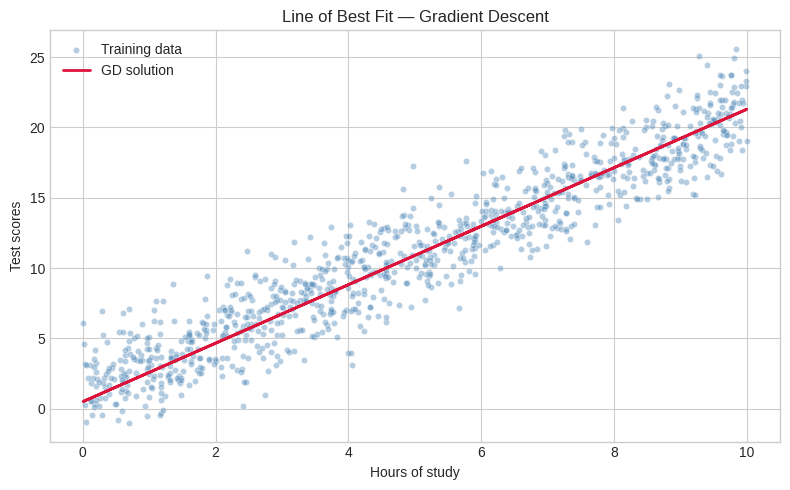

In [17]:
# Plot dataset and GD line of best fit
pred_gd = np.dot(X, optimized_theta_vector)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 1], y, alpha=0.4, edgecolors='white', linewidths=0.5,
            color='steelblue', label='Training data', s=20)
plt.plot(X[:, 1], pred_gd, color='crimson', linewidth=2, label='GD solution')
plt.xlabel('Hours of study')
plt.ylabel('Test scores')
plt.title('Line of Best Fit — Gradient Descent')
plt.legend()
plt.tight_layout()
plt.show()

*   Does the initial values of theta affect your results? Why?
*   At what point does the lr become too large? How do you know it?
*   How does a very small lr affect to the learning process?

## Bonus 1: The Normal Equation (Closed-Form Solution)

We can solve $\nabla_{\boldsymbol{\theta}}\mathcal{J} = 0$ analytically.

**Derivation:**
$$\nabla_{\boldsymbol{\theta}}\mathcal{J} = \frac{1}{m}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) = \mathbf{0}$$
$$\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} = \mathbf{X}^\top\mathbf{y}$$
$$\boxed{\boldsymbol{\theta}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}$$

This is the **Normal Equation**. The matrix $(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$ is the **Moore-Penrose pseudoinverse** $\mathbf{X}^+$ of $\mathbf{X}$.

**Computational comparison:**

| Method | Time Complexity | Space | When to prefer |
|--------|----------------|-------|----------------|
| Normal Equation | $O(n^3)$ (matrix inversion) | $O(n^2)$ | $n$ small ($n < 10^4$) |
| Gradient Descent | $O(k \cdot m \cdot n)$ per epoch | $O(mn)$ | $n$ large or $m$ very large |

**Numerical issues:** If $\mathbf{X}^\top\mathbf{X}$ is nearly singular (columns of $\mathbf{X}$ are nearly linearly dependent = **multicollinearity**), the inverse is ill-conditioned. The pseudoinverse or Ridge regression ($\boldsymbol{\theta}^* = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$) is more numerically stable.

> **Hint:** Use `np.linalg.inv()` (or better, `np.linalg.lstsq()` for numerical stability).

In [18]:
# Theta calculated from the Normal Equation: theta* = (X^T X)^{-1} X^T y
theta_normal_equation = np.linalg.inv(np.dot(X.T, X)).dot(X.T).dot(y)

In [19]:
ne_cost = compute_cost(theta_normal_equation, X, y)

print("-" * 45)
print("Normal Equation Results")
print("-" * 45)
print(f"  theta_0 (intercept) : {theta_normal_equation[0]:.6f}")
print(f"  theta_1 (slope)     : {theta_normal_equation[1]:.6f}")
print(f"  Minimised cost (MSE): {ne_cost:.6f}")
print("-" * 45)

---------------------------------------------
Normal Equation Results
---------------------------------------------
  theta_0 (intercept) : 1.154334
  theta_1 (slope)     : 1.980592
  Minimised cost (MSE): 1.865374
---------------------------------------------


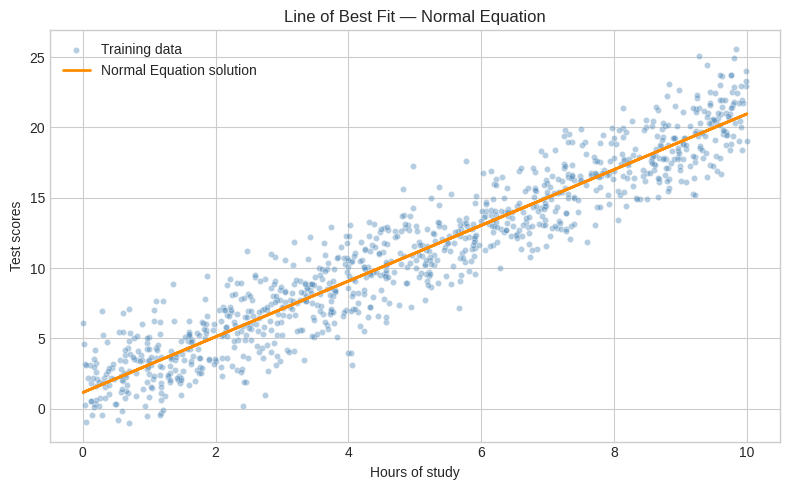

In [20]:
pred_ne = np.dot(X, theta_normal_equation)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 1], y, alpha=0.4, edgecolors='white', linewidths=0.5,
            color='steelblue', label='Training data', s=20)
plt.plot(X[:, 1], pred_ne, color='darkorange', linewidth=2, label='Normal Equation solution')
plt.xlabel('Hours of study')
plt.ylabel('Test scores')
plt.title('Line of Best Fit — Normal Equation')
plt.legend()
plt.tight_layout()
plt.show()

##Bonus 2:
In order to make our code run faster, we can vectorize our implementation.

In [21]:
def compute_cost_vectorized(theta, X, y):
    """
    vectorized version of cost_function(theta, X, y)
    """
    ## number of training examples
    m = len(y)

    ## Calculate the cost with the given parameters
    J = np.sum((y - X.dot(theta))**2) / (2*m)

    return J

In [22]:
import time

t0 = time.perf_counter()
J_loop = compute_cost(theta_normal_equation, X, y)
elapsed_loop = (time.perf_counter() - t0) * 1000

print(f"Loop version   — Cost: {J_loop:.6f}  |  Time: {elapsed_loop:.4f} ms")

Loop version   — Cost: 1.865374  |  Time: 3.6187 ms


In [23]:
t0 = time.perf_counter()
J_vec = compute_cost_vectorized(theta_normal_equation, X, y)
elapsed_vec = (time.perf_counter() - t0) * 1000

print(f"Vectorized     — Cost: {J_vec:.6f}  |  Time: {elapsed_vec:.4f} ms")
print(f"Speed-up       : {elapsed_loop / elapsed_vec:.1f}×  (loop vs vectorized)")

Vectorized     — Cost: 1.865374  |  Time: 0.3417 ms
Speed-up       : 10.6×  (loop vs vectorized)


### $R^2$ — Coefficient of Determination

The MSE tells us the absolute prediction error, but does not indicate how good the fit is relative to a baseline. The **coefficient of determination** measures the proportion of variance in $y$ explained by the model:

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}, \quad \text{where} \quad \text{SS}_{\text{res}} = \sum_{i=1}^m(y^{(i)} - \hat{y}^{(i)})^2, \quad \text{SS}_{\text{tot}} = \sum_{i=1}^m(y^{(i)} - \bar{y})^2$$

- $R^2 = 1$: perfect fit (model explains all variance)
- $R^2 = 0$: model performs no better than always predicting $\bar{y}$
- $R^2 < 0$: model is worse than the mean predictor (can happen on test set)

In [24]:
# R² - Coefficient of Determination
SS_tot = np.sum((y - np.mean(y))**2)

# Gradient Descent
y_pred_gd = np.dot(X, optimized_theta_vector)
SS_res_gd = np.sum((y - y_pred_gd)**2)
R2_gd = 1 - SS_res_gd / SS_tot
print(f"Gradient Descent  — MSE: {compute_cost(optimized_theta_vector, X, y):.4f} | R²: {R2_gd:.4f}")

# Normal Equation
y_pred_ne = np.dot(X, theta_normal_equation)
SS_res_ne = np.sum((y - y_pred_ne)**2)
R2_ne = 1 - SS_res_ne / SS_tot
print(f"Normal Equation   — MSE: {compute_cost(theta_normal_equation, X, y):.4f} | R²: {R2_ne:.4f}")
print(f"\nNote: both methods should converge to the same R² given sufficient GD iterations.")

Gradient Descent  — MSE: 1.9195 | R²: 0.8958
Normal Equation   — MSE: 1.8654 | R²: 0.8988

Note: both methods should converge to the same R² given sufficient GD iterations.


We can also implement the same kind of vectorizaton to the gradient descent uptdates.
We start by measuring the time needed for the current implementation.

In [25]:
t0 = time.perf_counter()
optimized_theta_vector, cost_graph, _ = gradient_descent(
    X, y, initial_theta_vector, learning_rate, num_iterations
)
elapsed_gd = (time.perf_counter() - t0) * 1000

print(f"  theta_0: {optimized_theta_vector[0]:.6f}")
print(f"  theta_1: {optimized_theta_vector[1]:.6f}")
print(f"  Time   : {elapsed_gd:.2f} ms")

  theta_0: 0.503681
  theta_1: 2.079002
  Time   : 475.06 ms


And now rewrite the critital step part of the algorithm.

In [26]:
def step_gradient(theta_current, X, y, alpha):
    """
    vectorized version of step_gradient(theta_current, X, y, alpha)
    """

    m = float(len(y))

    hypothesis_vector = X.dot(theta_current)

    loss = hypothesis_vector-y.squeeze()

    theta_gradient = X.T.dot(loss) / m

    theta_updated = theta_current - alpha*theta_gradient

    #Return updated parameters
    return theta_updated

In [27]:
t0 = time.perf_counter()
optimized_theta_vector, cost_graph, _ = gradient_descent(
    X, y, initial_theta_vector, learning_rate, num_iterations
)
elapsed_vgd = (time.perf_counter() - t0) * 1000

print(f"  theta_0: {optimized_theta_vector[0]:.6f}")
print(f"  theta_1: {optimized_theta_vector[1]:.6f}")
print(f"  Time   : {elapsed_vgd:.2f} ms")
print(f"  Speed-up vs loop GD: {elapsed_gd / elapsed_vgd:.1f}×")

  theta_0: 0.503681
  theta_1: 2.079002
  Time   : 140.32 ms
  Speed-up vs loop GD: 3.4×


Please note that this is a very "small" model and dataset. Vectorizing becomes much more important (and helpful) for larger datasets and features spaces.

## Extension: Multiple Linear Regression ($n > 1$)

The beauty of the matrix formulation is that **everything generalises immediately** to multiple features. Let us demonstrate with a 2-feature synthetic example.

The model is: $\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2$

We generate data from $y = 3 + 2x_1 - 1.5x_2 + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, 1)$.

True θ:      [ 3.   2.  -1.5]
Estimated θ: [ 3.106  2.008 -1.439]
R² = 0.8542


<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3110/3995777828.py:27: SyntaxWarning: invalid escape sequence '\h'
  axes[0].set_xlabel('Fitted values $\hat{y}$'); axes[0].set_ylabel('Residuals')


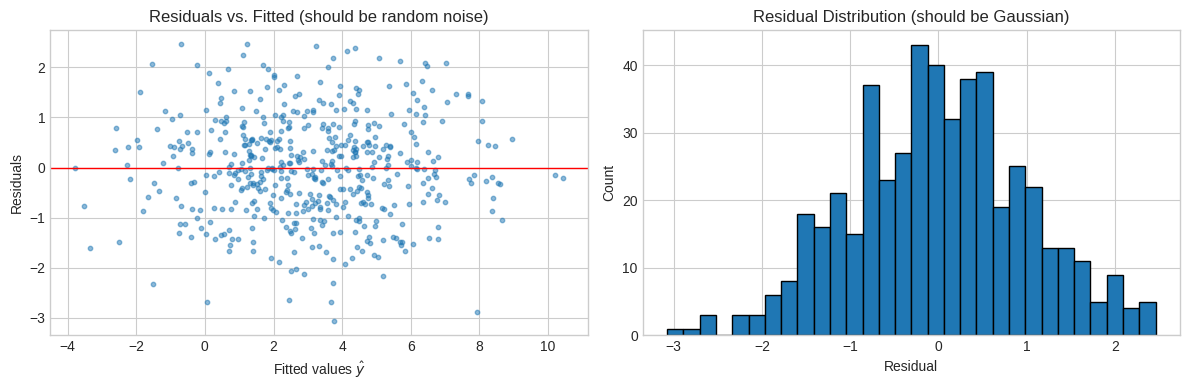

In [28]:
# Multiple Linear Regression — 2 features
np.random.seed(42)
m2 = 500
X2_raw = np.random.randn(m2, 2)           # 2 features
theta_true = np.array([3.0, 2.0, -1.5])  # true: theta0=3, theta1=2, theta2=-1.5
y2 = X2_raw @ theta_true[1:] + theta_true[0] + np.random.randn(m2)

# Augment with bias column
X2 = np.concatenate([np.ones((m2, 1)), X2_raw], axis=1)

# Normal Equation
theta_mlr = np.linalg.lstsq(X2, y2, rcond=None)[0]
print(f"True θ:      {theta_true}")
print(f"Estimated θ: {theta_mlr.round(3)}")

# R²
y2_pred = X2 @ theta_mlr
SS_tot2 = np.sum((y2 - np.mean(y2))**2)
R2_mlr = 1 - np.sum((y2 - y2_pred)**2) / SS_tot2
print(f"R² = {R2_mlr:.4f}")

# Residual plot
residuals = y2 - y2_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y2_pred, residuals, alpha=0.5, s=10)
axes[0].axhline(0, color='r', linewidth=1)
axes[0].set_xlabel('Fitted values $\hat{y}$'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted (should be random noise)')

axes[1].hist(residuals, bins=30, edgecolor='k')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (should be Gaussian)')
plt.tight_layout(); plt.show()

## Reflection Questions

1. **Assumptions of linear regression.** What are the Gauss-Markov assumptions? Which of the following violates them: heteroscedasticity, autocorrelation, multicollinearity? What diagnostic plots help detect violations?

2. **Convexity.** Prove that the MSE cost $\mathcal{J}(\boldsymbol{\theta}) = \frac{1}{2m}\|\mathbf{X}\boldsymbol{\theta}-\mathbf{y}\|^2$ is convex. What is its Hessian? Under what condition is it *strictly* convex?

3. **Learning rate selection.** The gradient descent update is stable when $\alpha < \frac{2}{\lambda_{\max}(\frac{1}{m}\mathbf{X}^\top\mathbf{X})}$. How would you estimate $\lambda_{\max}$ in practice? What happens when $\alpha$ is too large?

4. **Normal Equation vs. Gradient Descent.** The Normal Equation requires $O(n^3)$ operations for matrix inversion. At what scale of $n$ would you switch to gradient descent? What about iterative solvers like Conjugate Gradient?

5. **Regularization.** If $\mathbf{X}^\top\mathbf{X}$ is singular, the Normal Equation has no unique solution. How does Ridge regression ($L_2$ regularization) resolve this? Show that $\boldsymbol{\theta}_{\text{Ridge}}^* = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$ is always unique for $\lambda > 0$.

## Answers to Reflection Questions

**1. Assumptions of linear regression (Gauss-Markov).**
The five classical assumptions are:
- **L**inearity: $y = \mathbf{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$ (the conditional mean of $y$ is linear in $\mathbf{x}$)
- **I**ndependence: errors $\varepsilon^{(i)}$ are independent across observations (no autocorrelation)
- **H**omoscedasticity: $\text{Var}(\varepsilon^{(i)}) = \sigma^2$ (constant variance — no heteroscedasticity)
- **N**ormality: $\varepsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)$ (required for inference, not for point estimates)
- **No perfect multicollinearity**: columns of $\mathbf{X}$ are linearly independent

Under (L, I, H) the Gauss-Markov theorem guarantees OLS is BLUE (Best Linear Unbiased Estimator).

*Diagnostic plots:* residuals vs. fitted (detects heteroscedasticity, non-linearity), Q-Q plot of residuals (detects non-normality), leverage/Cook's distance (detects influential points).

---

**2. Convexity of the MSE cost.**
$$\mathcal{J}(\boldsymbol{\theta}) = \frac{1}{2m}\|\mathbf{X}\boldsymbol{\theta}-\mathbf{y}\|^2 = \frac{1}{2m}\boldsymbol{\theta}^\top\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} - \frac{1}{m}\mathbf{y}^\top\mathbf{X}\boldsymbol{\theta} + \text{const}$$

The Hessian is $\mathbf{H} = \frac{1}{m}\mathbf{X}^\top\mathbf{X}$. Since $\mathbf{X}^\top\mathbf{X}$ is always positive semi-definite (for any $\mathbf{v}$: $\mathbf{v}^\top\mathbf{X}^\top\mathbf{X}\mathbf{v} = \|\mathbf{X}\mathbf{v}\|^2 \geq 0$), the cost is **convex**. It is *strictly* convex iff $\mathbf{X}^\top\mathbf{X}$ is positive definite, which holds when the columns of $\mathbf{X}$ are linearly independent (no perfect multicollinearity).

---

**3. Learning rate selection.**
Gradient descent is stable when $\alpha < \frac{2}{\lambda_{\max}(\mathbf{H})} = \frac{2m}{\lambda_{\max}(\mathbf{X}^\top\mathbf{X})}$. In practice, estimate $\lambda_{\max}$ by running a few gradient steps and checking whether the cost is decreasing, or via the power iteration method. When $\alpha$ is too large, the update overshoots the minimum and the cost can diverge ($\mathcal{J}$ grows monotonically).

---

**4. Normal Equation vs. Gradient Descent.**
The Normal Equation's $O(n^3)$ cost becomes prohibitive around $n \sim 10^4$. For $m \gg n$ (more samples than features, tall-and-thin $\mathbf{X}$), gradient descent with $O(mn)$ per step is much faster. Iterative solvers like Conjugate Gradient can solve the linear system $\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} = \mathbf{X}^\top\mathbf{y}$ in $O(n^2)$ time (for well-conditioned matrices), offering a middle ground.

---

**5. Regularisation and singularity.**
Ridge regression adds $\lambda\mathbf{I}$: $\boldsymbol{\theta}^* = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$. Since $\mathbf{X}^\top\mathbf{X}$ is PSD, its eigenvalues $\lambda_i \geq 0$; adding $\lambda\mathbf{I}$ shifts them to $\lambda_i + \lambda > 0$, making the matrix **positive definite** and always invertible. This also improves the condition number: $\kappa(\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I}) = \frac{\lambda_{\max} + \lambda}{\lambda_{\min} + \lambda} < \frac{\lambda_{\max}}{\lambda_{\min}} = \kappa(\mathbf{X}^\top\mathbf{X})$.